#### 1. Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load data
df = pd.read_csv('penguins.csv')

# HINT: Check structure first
print("\n----->head\n")
print(df.head())

print("\n----->shape\n")
print(df.shape)

print("\n----->data types/missing\n")
print(df.info())

print("\n----->numerical summary\n")
print(df.describe())



----->head

   rowid species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0      1  Adelie  Torgersen            39.1           18.7              181.0   
1      2  Adelie  Torgersen            39.5           17.4              186.0   
2      3  Adelie  Torgersen            40.3           18.0              195.0   
3      4  Adelie  Torgersen             NaN            NaN                NaN   
4      5  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

----->shape

(344, 9)

----->data types/missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species    

#### 2. Clean data

In [14]:
df_clean = df.dropna(subset=['bill_length_mm',
'flipper_length_mm']).copy()
df_clean['sex'] = df_clean['sex'].fillna('Unknown')

# Should be 0 for analysis columns
print(f"df_clean.isnull().sum():\n{df_clean.isnull().sum()}")

print(f"\nspecies count:\n{df_clean['species'].value_counts()}")
# Check species balance: Adelie(152), Gentoo(124), Chinstrap(52)


df_clean.isnull().sum():
rowid                0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

species count:
Adelie       151
Gentoo       123
Chinstrap     68
Name: species, dtype: int64


#### 3. Four Visualizations

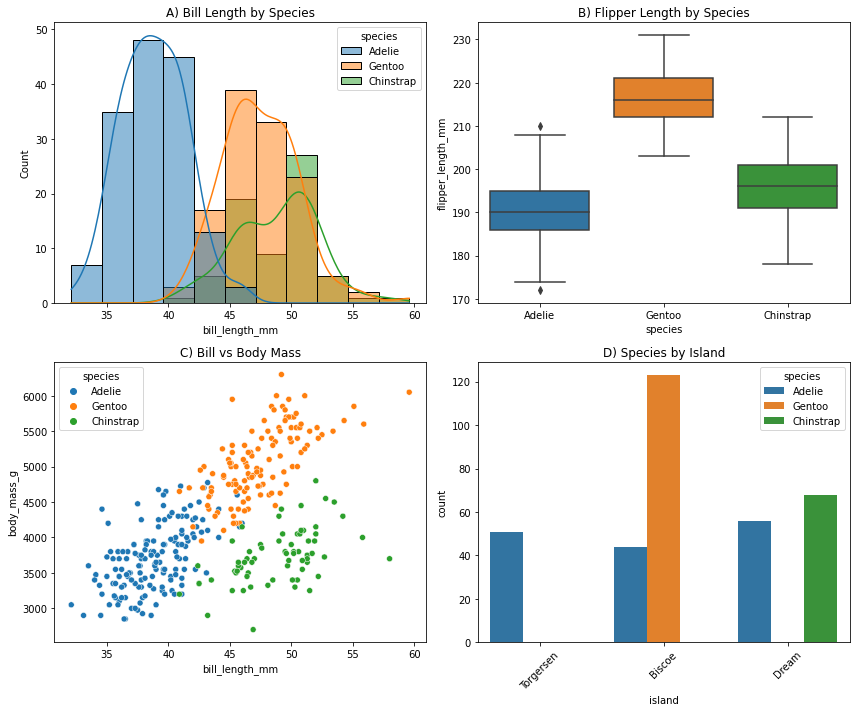

In [31]:
# Create figure
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# A) Histogram with KDE
sns.histplot(data=df_clean, x='bill_length_mm', hue='species',
kde=True, ax=ax[0,0])
ax[0,0].set_title('A) Bill Length by Species')

# B) Boxplot
sns.boxplot(data=df_clean, x='species', y='flipper_length_mm',
ax=ax[0,1])
ax[0,1].set_title('B) Flipper Length by Species')

# C) Scatterplot
sns.scatterplot(data=df_clean, x='bill_length_mm',
y='body_mass_g', hue='species', ax=ax[1,0])
ax[1,0].set_title('C) Bill vs Body Mass')

# D) Countplot
sns.countplot(data=df_clean, x='island', hue='species',
ax=ax[1,1])
ax[1,1].set_title('D) Species by Island') # Rotate if overlapping:
plt.xticks(rotation=45)

# Show
plt.tight_layout()

plt.savefig(
    "figure.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()




#### 4. Insights Table
-> 3 Observations and implications

Bill length:
- Adelie - shortests.
- Gentoo - longest.
- Chinstrap - in between.

Flipper length:
- Adelie - shortest.
- Gentoo - longest.
- Chinstrap - in between.

Bill vs. body mass:
- There seems to be a correlation between the two within each species and for all species.
- However, Chinstrap has longer bill length per body mass compared to Adelie and Gentoo.

Species by island:
- Torgersen - Adelie only
- Biscoue - Adelie and Gentoo, mostly Gentoo
- Dream - Adelie and Chinstrap


#### 5. Correlation heatmap + pairplot

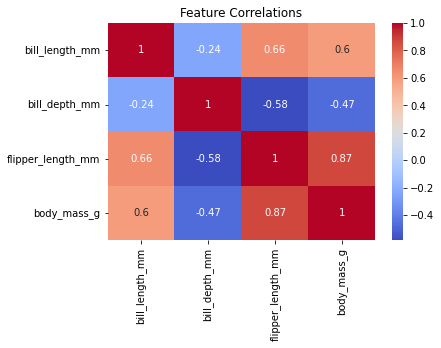

In [29]:
corr = df_clean[['bill_length_mm','bill_depth_mm', 'flipper_length_mm','body_mass_g']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()